In [1]:
import torch
import torchvision
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from torch import nn, optim
from pathlib import Path
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
 
print("PyTorch version:", torch.__version__)
print("All imports successful!")

PyTorch version: 2.12.0+cpu
All imports successful!


In [2]:

DATA_ROOT = Path(r"C:\Users\User\Desktop\industrial defect detection\data\mvtec")
CATEGORY  = "leather"       
IMG_SIZE  = 224               
BATCH     = 16
EPOCHS    = 10
LR        = 0.001
 
cat_path  = DATA_ROOT / CATEGORY
print(f"Working with category: {CATEGORY}")
print(f"Train folder: {cat_path / 'train'}")
print(f"Test folder:  {cat_path / 'test'}")

Working with category: leather
Train folder: C:\Users\User\Desktop\industrial defect detection\data\mvtec\leather\train
Test folder:  C:\Users\User\Desktop\industrial defect detection\data\mvtec\leather\test


In [3]:
class MVTecDataset(Dataset):
    def __init__(self, root, split="train", transform=None):
        self.transform = transform
        self.images = []
        self.labels = []
 
        if split == "train":
            # Training: only 'good' images → label 0
            good_folder = root / "train" / "good"
            for img_path in sorted(good_folder.glob("*.png")):
                self.images.append(img_path)
                self.labels.append(0)  # 0 = good
 
        elif split == "test":
            test_root = root / "test"
            for subfolder in sorted(test_root.iterdir()):
                if not subfolder.is_dir():
                    continue
                label = 0 if subfolder.name == "good" else 1  # 1 = defective
                for img_path in sorted(subfolder.glob("*.png")):
                    self.images.append(img_path)
                    self.labels.append(label)
 
        print(f"  {split}: {len(self.images)} images | "
              f"good={self.labels.count(0)} | defective={self.labels.count(1)}")
 
    def __len__(self):
        return len(self.images)
 
    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
 
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),       # data augmentation
    transforms.RandomVerticalFlip(),         # data augmentation
    transforms.ColorJitter(brightness=0.2),  # data augmentation
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
 
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
 
print("Transforms defined.")
print("Train transform: resize + augmentation + normalize")
print("Test transform:  resize + normalize only (no augmentation)")

Transforms defined.
Train transform: resize + augmentation + normalize
Test transform:  resize + normalize only (no augmentation)


In [5]:
print("Loading datasets...")
train_dataset = MVTecDataset(cat_path, split="train", transform=train_transform)
test_dataset  = MVTecDataset(cat_path, split="test",  transform=test_transform)
 
train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False)
 
print(f"\nDataLoader ready!")
print(f"Training batches: {len(train_loader)} batches × {BATCH} images = ~{len(train_loader)*BATCH} images")
print(f"Test batches:     {len(test_loader)} batches × {BATCH} images = ~{len(test_loader)*BATCH} images")
 
# Quick sanity check — visualize one batch
images, labels = next(iter(train_loader))
print(f"\nOne batch shape: {images.shape}")
print(f"  → {images.shape[0]} images, {images.shape[1]} channels, "
      f"{images.shape[2]}×{images.shape[3]} pixels")
 

Loading datasets...
  train: 245 images | good=245 | defective=0
  test: 124 images | good=32 | defective=92

DataLoader ready!
Training batches: 16 batches × 16 images = ~256 images
Test batches:     8 batches × 16 images = ~128 images

One batch shape: torch.Size([16, 3, 224, 224])
  → 16 images, 3 channels, 224×224 pixels


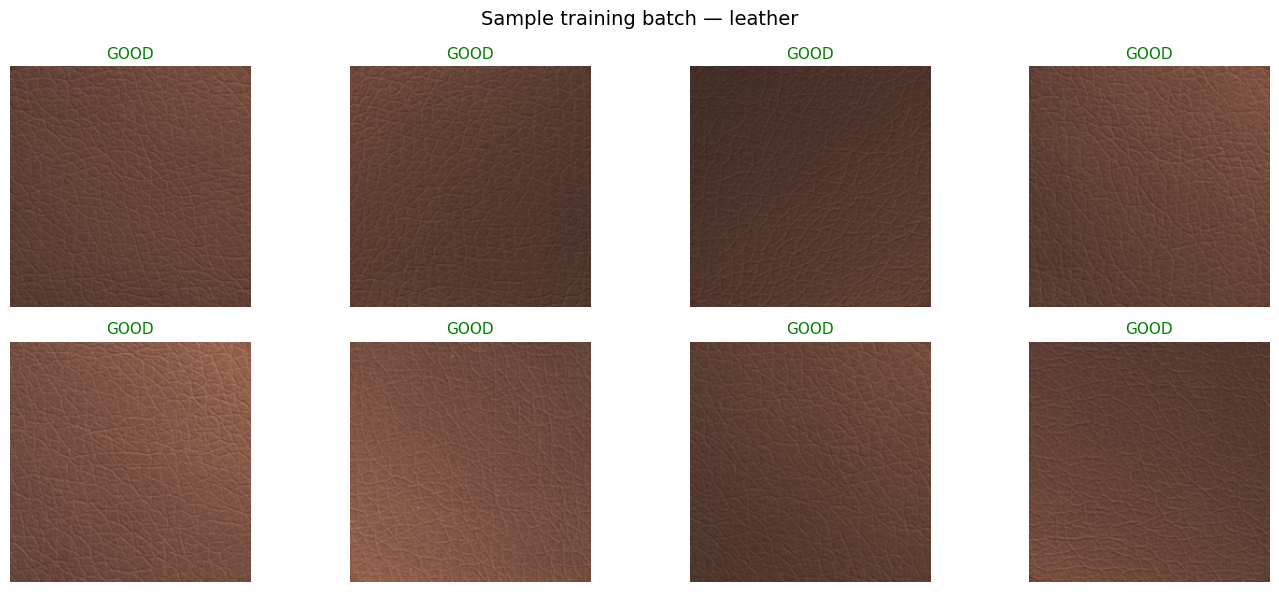

In [6]:
def denormalize(tensor):
    """Undo normalization so we can display the image"""
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)
 
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    if i >= len(images): break
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    label_text = "GOOD" if labels[i] == 0 else "DEFECTIVE"
    color = "green" if labels[i] == 0 else "red"
    ax.imshow(img)
    ax.set_title(label_text, color=color, fontsize=11)
    ax.axis("off")
 
plt.suptitle(f"Sample training batch — {CATEGORY}", fontsize=14)
plt.tight_layout()
plt.savefig("../notebooks/sample_batch.png", dpi=120, bbox_inches="tight")
plt.show()

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("(CPU is fine — training will take ~5-10 min on CPU)\n")
 
# Load ResNet18 pre-trained on ImageNet
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
 
for param in model.parameters():
    param.requires_grad = False
 
num_features = model.fc.in_features  # = 512 for ResNet18
model.fc = nn.Linear(num_features, 2)
 
# Move model to device 
model = model.to(device)
 
# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Total parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}  (only the last layer!)")
print(f"Frozen parameters:    {total - trainable:,}")
print("\nModel ready!")

Using device: cpu
(CPU is fine — training will take ~5-10 min on CPU)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\User/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:09<00:00, 5.20MB/s]


Total parameters:     11,177,538
Trainable parameters: 1,026  (only the last layer!)
Frozen parameters:    11,176,512

Model ready!


In [8]:
criterion = nn.CrossEntropyLoss()    
optimizer = optim.Adam(model.fc.parameters(), lr=LR)  # only optimize last layer
 
print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam (only training the final layer)")

Loss function: CrossEntropyLoss
Optimizer: Adam (only training the final layer)


In [9]:
train_losses = []
train_accs   = []
 
print(f"Starting training for {EPOCHS} epochs...\n")
 
for epoch in range(EPOCHS):
    model.train()
    running_loss    = 0.0
    correct         = 0
    total_samples   = 0
 
    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)
 
        # 1. Forward pass — run images through model
        outputs = model(images)
 
        # 2. Calculate loss 
        loss = criterion(outputs, labels)
 
        # 3. Backward pass — figure out how to improve
        optimizer.zero_grad()
        loss.backward()
 
        # 4. Update weights
        optimizer.step()
 
        # Track stats
        running_loss  += loss.item()
        _, predicted   = outputs.max(1)
        correct       += predicted.eq(labels).sum().item()
        total_samples += labels.size(0)
 
    epoch_loss = running_loss / len(train_loader)
    epoch_acc  = 100. * correct / total_samples
    train_losses.append(epoch_loss)
    train_accs.append(epoch_acc)
 
    print(f"Epoch [{epoch+1:2d}/{EPOCHS}] | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.1f}%")
 
print("\nTraining complete!")


Starting training for 10 epochs...

Epoch [ 1/10] | Loss: 0.1454 | Accuracy: 90.6%
Epoch [ 2/10] | Loss: 0.0004 | Accuracy: 100.0%
Epoch [ 3/10] | Loss: 0.0002 | Accuracy: 100.0%
Epoch [ 4/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [ 5/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [ 6/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [ 7/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [ 8/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [ 9/10] | Loss: 0.0001 | Accuracy: 100.0%
Epoch [10/10] | Loss: 0.0001 | Accuracy: 100.0%

Training complete!


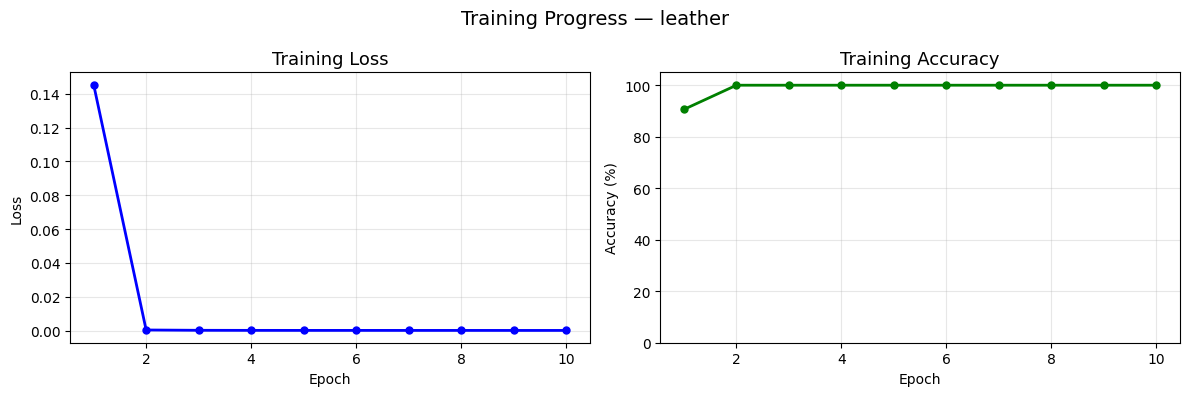

Training curves saved!


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
 
ax1.plot(range(1, EPOCHS+1), train_losses, 'b-o', linewidth=2, markersize=5)
ax1.set_title("Training Loss", fontsize=13)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, alpha=0.3)
 
ax2.plot(range(1, EPOCHS+1), train_accs, 'g-o', linewidth=2, markersize=5)
ax2.set_title("Training Accuracy", fontsize=13)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim([0, 105])
ax2.grid(True, alpha=0.3)
 
plt.suptitle(f"Training Progress — {CATEGORY}", fontsize=14)
plt.tight_layout()
plt.savefig(f"../notebooks/training_curves_{CATEGORY}.png", dpi=120, bbox_inches="tight")
plt.show()
print("Training curves saved!")

In [11]:
model.eval()  # switch to evaluation mode (disables dropout etc.)
 
all_preds  = []
all_labels = []
 
with torch.no_grad():  # don't compute gradients during evaluation
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())
 
# Calculate metrics
report = classification_report(
    all_labels, all_preds,
    target_names=["Good", "Defective"],
    digits=3
)
print("=" * 50)
print("TEST SET RESULTS")
print("=" * 50)
print(report)


TEST SET RESULTS
              precision    recall  f1-score   support

        Good      0.258     1.000     0.410        32
   Defective      0.000     0.000     0.000        92

    accuracy                          0.258       124
   macro avg      0.129     0.500     0.205       124
weighted avg      0.067     0.258     0.106       124



C:\Users\User\Desktop\industrial defect detection\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Desktop\industrial defect detection\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\User\Desktop\industrial defect detection\venv\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

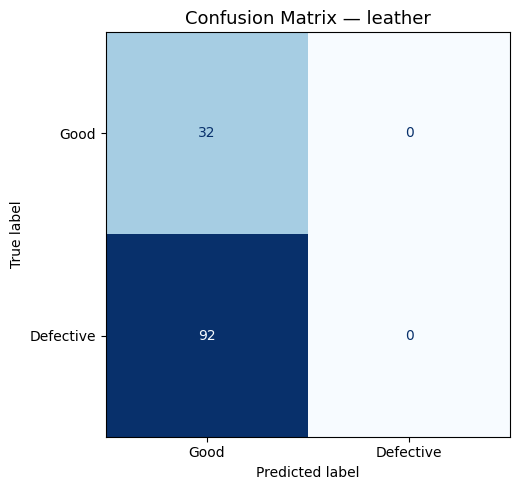


Reading the matrix:
  True Negatives  (correctly said GOOD):      32
  True Positives  (correctly said DEFECTIVE):  0
  False Positives (said DEFECTIVE, was GOOD):  0  ← Type I error
  False Negatives (said GOOD, was DEFECTIVE):  92  ← Type II error

In industry, False Negatives are the dangerous ones —
  missing a real defect is worse than a false alarm.


In [12]:
cm = confusion_matrix(all_labels, all_preds)
 
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Good", "Defective"])
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(f"Confusion Matrix — {CATEGORY}", fontsize=13)
 
plt.tight_layout()
plt.savefig(f"../notebooks/confusion_matrix_{CATEGORY}.png", dpi=120, bbox_inches="tight")
plt.show()
 
# Explain what you're seeing
tn, fp, fn, tp = cm.ravel()
print(f"\nReading the matrix:")
print(f"  True Negatives  (correctly said GOOD):      {tn}")
print(f"  True Positives  (correctly said DEFECTIVE):  {tp}")
print(f"  False Positives (said DEFECTIVE, was GOOD):  {fp}  ← Type I error")
print(f"  False Negatives (said GOOD, was DEFECTIVE):  {fn}  ← Type II error")
print(f"\nIn industry, False Negatives are the dangerous ones —")
print(f"  missing a real defect is worse than a false alarm.")

In [13]:
import os
save_dir = Path(r"C:\Users\User\Desktop\industrial defect detection\outputs\models")
save_dir.mkdir(parents=True, exist_ok=True)
 
save_path = save_dir / f"resnet18_{CATEGORY}.pth"
torch.save(model.state_dict(), save_path)
print(f"Model saved to: {save_path}")
print("\nTo load this model later:")
print(f'  model.load_state_dict(torch.load(r"{save_path}"))')
 

Model saved to: C:\Users\User\Desktop\industrial defect detection\outputs\models\resnet18_leather.pth

To load this model later:
  model.load_state_dict(torch.load(r"C:\Users\User\Desktop\industrial defect detection\outputs\models\resnet18_leather.pth"))


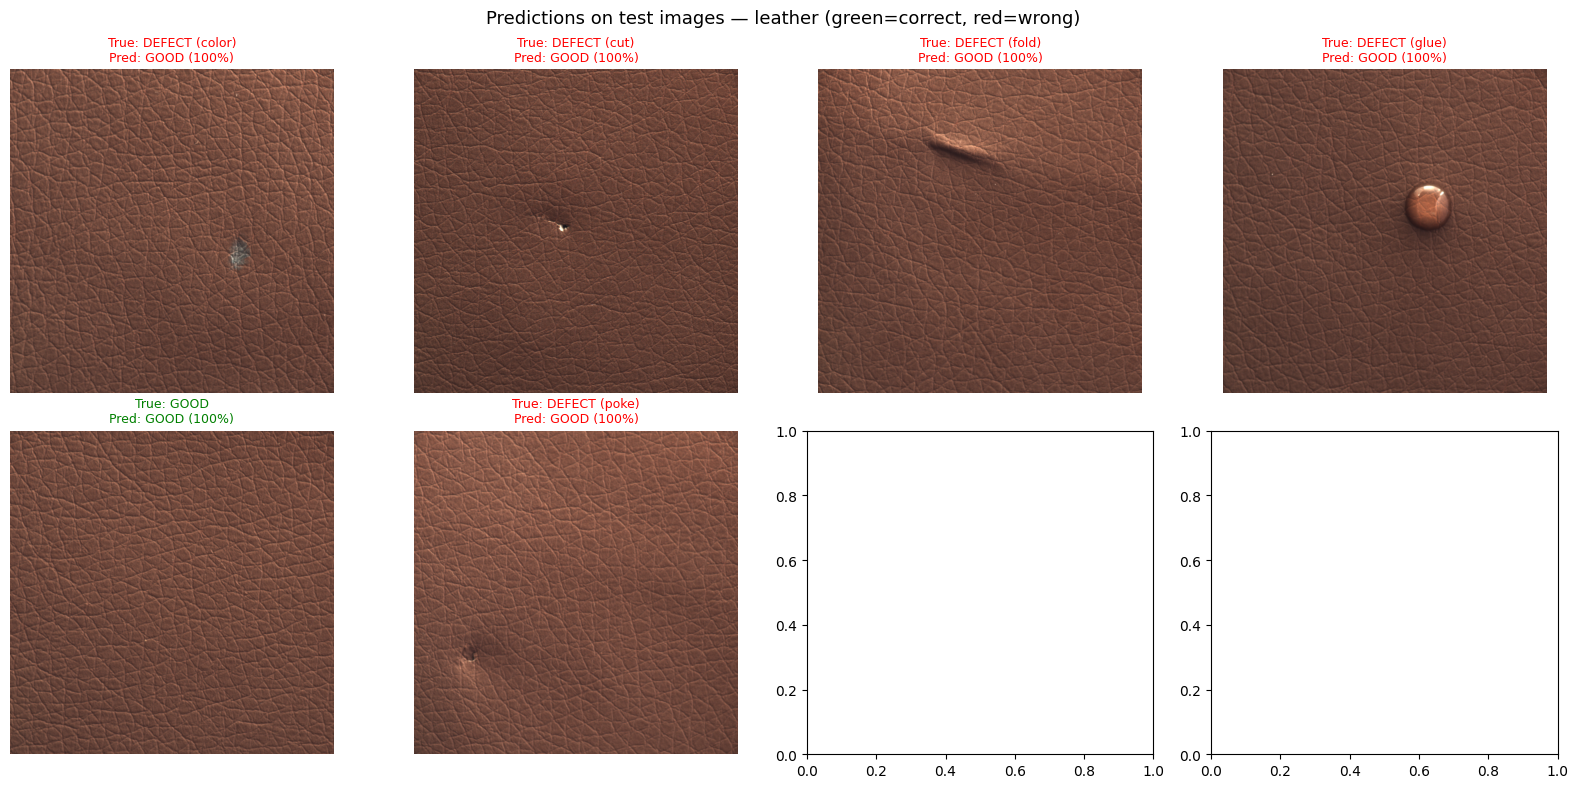

Prediction visualization saved!


In [14]:
model.eval()
 
# Pick some test images to visualize
test_samples = []
test_root = cat_path / "test"
 
for subfolder in sorted(test_root.iterdir()):
    if subfolder.is_dir():
        imgs = list(subfolder.glob("*.png"))
        if imgs:
            test_samples.append((imgs[0], subfolder.name))
    if len(test_samples) >= 8:
        break
 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
 
for i, (img_path, true_label) in enumerate(test_samples[:8]):
    ax = axes[i // 4][i % 4]
 
    # Load and preprocess
    img_pil = Image.open(img_path).convert("RGB")
    tensor  = test_transform(img_pil).unsqueeze(0).to(device)
 
    # Predict
    with torch.no_grad():
        output = model(tensor)
        probs  = torch.softmax(output, dim=1)[0]
        pred   = output.argmax(1).item()
 
    pred_label = "DEFECTIVE" if pred == 1 else "GOOD"
    true_class = "GOOD" if true_label == "good" else f"DEFECT ({true_label})"
    confidence = probs[pred].item() * 100
 
    # Determine if prediction is correct
    true_is_defective = (true_label != "good")
    pred_is_defective = (pred == 1)
    correct = (true_is_defective == pred_is_defective)
    border_color = "green" if correct else "red"
 
    ax.imshow(img_pil)
    ax.set_title(
        f"True: {true_class}\nPred: {pred_label} ({confidence:.0f}%)",
        fontsize=9,
        color=border_color
    )
    ax.axis("off")
    for spine in ax.spines.values():
        spine.set_edgecolor(border_color)
        spine.set_linewidth(3)
        spine.set_visible(True)
 
plt.suptitle(f"Predictions on test images — {CATEGORY} (green=correct, red=wrong)", fontsize=13)
plt.tight_layout()
plt.savefig(f"../notebooks/predictions_{CATEGORY}.png", dpi=120, bbox_inches="tight")
plt.show()
print("Prediction visualization saved!")